# 🏥 Laboratório Prático — A Batalha dos Modelos: KNN vs Árvore de Decisão
### Diagnóstico de Câncer de Mama

**Módulo:** Fundamentação em Machine Learning — Semana 11
**Aula:** 3 de 3 (Laboratório Prático)
**Duração total:** 2h30min (150 minutos)
**Pré-requisitos:** Aula 1 (KNN) e Aula 2 (Árvore de Decisão)

---

## 🎯 O Cenário

Vocês fazem parte de uma equipe júnior de Ciência de Dados contratada por um **hospital** para
desenvolver um modelo de apoio ao diagnóstico de câncer de mama. O objetivo é classificar
tumores como **malignos** ou **benignos** a partir de medidas extraídas de exames de imagem.

O hospital pediu que a equipe **compare dois modelos diferentes** — KNN e Árvore de Decisão —
e entregue uma **recomendação justificada** sobre qual modelo é mais adequado para apoiar a
equipe médica, considerando não só a acurácia, mas também:

- O risco de **falsos negativos** (dizer que o tumor é benigno quando na verdade é maligno — o
  erro mais perigoso em um contexto clínico);
- A **interpretabilidade** do modelo para médicos que não são especialistas em ML.

Vocês vão implementar o pipeline completo: carregar os dados, pré-processar, treinar os dois
modelos, compará-los e escrever um pequeno relatório de recomendação para o hospital.

---

## ⚠️ Regras do Laboratório

- Este notebook contém **apenas instruções**. Vocês devem escrever todo o código.
- Sigam a ordem das seções — cada uma se apoia na anterior.
- Fiquem de olho no tempo sugerido em cada etapa (é um guia, não uma regra rígida).
- Se travarem por mais de 5-10 minutos em algo, chamem a mentora.
- Ao final, cada grupo deve ter um notebook rodando do início ao fim + o relatório da
  Parte 6 preenchido.

## ⏱️ Roteiro de Tempo Sugerido

| Etapa | Conteúdo | Tempo |
|---|---|---|
| 0 | Setup do ambiente | 5 min |
| 1 | Exploração dos dados | 15 min |
| 2 | Pré-processamento | 15 min |
| 3 | Modelo 1: KNN | 35 min |
| 4 | Modelo 2: Árvore de Decisão | 35 min |
| 5 | Comparação final entre os modelos | 25 min |
| 6 | Relatório de recomendação para o hospital | 15 min |
| — | Buffer / dúvidas / ajustes finais | 5 min |
| **Total** | | **150 min** |


---
## 🔧 Parte 0 — Setup do Ambiente (~5 min)

Importem todas as bibliotecas que vocês vão precisar ao longo do laboratório. Pensem no que já
usaram nas aulas 1 e 2:

- Manipulação de dados: `pandas`
- Visualização: `matplotlib.pyplot`, `seaborn`
- O dataset de câncer de mama (já vem embutido no scikit-learn) - ´scikit_learn´
- Separação treino/teste
- Padronização/escalonamento de dados
- O classificador KNN
- O classificador de Árvore de Decisão
- Métricas de avaliação: relatório de classificação e matriz de confusão

**Dica:** todas essas ferramentas já foram usadas nas duas aulas anteriores. Revisem seus
notebooks das Aulas 1 e 2 se precisarem relembrar os nomes exatos dos módulos.

In [46]:
# Seu código aqui
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

---
## 🔍 Parte 1 — Exploração dos Dados (~15 min)

O hospital forneceu um conjunto de dados com medidas extraídas digitalmente de exames de
imagem de tumores de mama (o dataset `load_breast_cancer` do scikit-learn).

**Façam:**

1. Carreguem o dataset e criem um `DataFrame` do pandas com as *features* (`X`) e uma `Series`
   com o alvo (`y`). Lembrem-se: no dataset original, `0 = maligno` e `1 = benigno`.
2. Mostrem as 5 primeiras linhas de `X` e de `y`.
3. Verifiquem quantas *features* (colunas) e quantas amostras (linhas) existem no total.
4. Verifiquem se existem valores ausentes (nulos) nos dados.
5. Analisem o **balanceamento das classes**: quantos casos malignos e quantos benignos existem?
   Isso é relevante para o hospital? Por quê?
6. (Opcional, se der tempo) Façam um gráfico simples (ex: `countplot` do seaborn) mostrando a
   distribuição das classes.

**Perguntas para pensar (anotem a resposta em uma célula de markdown):**
- As classes estão balanceadas ou desbalanceadas? Isso importa no diagnóstico médico?
- Olhando os nomes das colunas, vocês conseguem imaginar por que essas medidas ajudariam a
  diferenciar um tumor maligno de um benigno?

In [47]:
# Seu código aqui
data = load_breast_cancer(as_frame=True)
df_breast_cancer = data.frame

y = df_breast_cancer['target']
X = df_breast_cancer.drop(columns=['target'])

In [48]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [49]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [50]:
print("Numero de linhas e colunas das features")
print(X.shape)

print("Valores ausentes em cada coluna")
print(X.info())

Numero de linhas e colunas das features
(569, 30)
Valores ausentes em cada coluna
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area erro

In [51]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

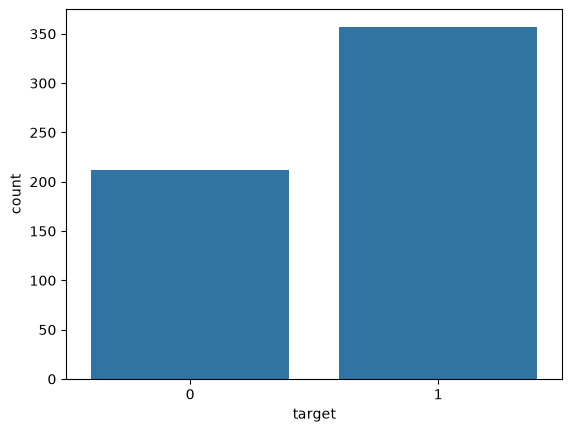

In [52]:
sns.countplot(df_breast_cancer, x="target")
plt.show()

**Respostas (Parte 1):**

_Escrevam aqui as respostas das perguntas acima._

1- As classes estão desbalanceadas, a quantidade de cancêres benigno é maior do que a de cancêres malignos
2- Acredito que as colunas presentes ajudam a identificar o cancêr pelo estado físico do tumor

---
## ⚙️ Parte 2 — Pré-processamento (~15 min)

Antes de treinar qualquer modelo, os dados precisam estar prontos.

**Façam:**

1. Dividam os dados em treino e teste (sugestão: 80% treino / 20% teste). Usem uma divisão
   **estratificada** — pensem em por que isso é especialmente importante neste problema.
2. Fixem uma semente aleatória (`random_state`) para que o experimento seja reprodutível.
3. Apliquem o **escalonamento** (padronização) das features de treino e teste.

**Perguntas para pensar (respondam em markdown):**
- Por que o escalonamento é indispensável para o KNN, mas não é obrigatório para a Árvore de
  Decisão? Relembrem como cada algoritmo funciona internamente (distâncias vs. regras de
  divisão).
- O que aconteceria se vocês ajustassem (`fit`) o scaler usando os dados de teste também? Por
  que isso seria um erro (dica: *data leakage*)?

In [53]:
# Seu código aqui
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

standard_scaler = StandardScaler()

X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)


**Respostas (Parte 2):**

_Escrevam aqui as respostas das perguntas acima._



---
## 🔵 Parte 3 — Modelo 1: KNN (~35 min)

Agora treinem o primeiro modelo.

**Façam:**

1. Treinem um `KNeighborsClassifier` com um valor inicial de `k` (número de vizinhos) à sua
   escolha (ex: k=5) sobre os dados de treino padronizados.
2. Façam as previsões sobre o conjunto de teste.
3. Avaliem o modelo com um relatório de classificação (precision, recall, f1-score) e uma
   matriz de confusão.
4. **Testem pelo menos 3 valores diferentes de `k`** (por exemplo, 3, 5, 7, 9, 15) e comparem os
   resultados. Uma tabela ou um gráfico simples de acurácia (ou recall) por valor de `k` ajuda
   bastante na visualização.
5. Escolham o valor de `k` que vocês considerarem melhor para o contexto do problema e
   justifiquem a escolha.

**Perguntas para pensar (respondam em markdown):**
- No relatório de classificação, qual métrica vocês acham mais importante observar para a
  classe "maligno" neste contexto hospitalar? Por quê?
- O que aconteceu com o desempenho do modelo quando `k` era muito pequeno? E quando era muito
  grande? Isso tem relação com overfitting/underfitting?


In [54]:
# Seu código aqui
knn_3 = KNeighborsClassifier(n_neighbors=3)
knn_3.fit(X_train, y_train)
knn_3_pred = knn_3.predict(X_test)

print("Accuracy:", accuracy_score(y_test, knn_3_pred))
print()
print(classification_report(y_test, knn_3_pred, zero_division=0))

Accuracy: 0.9298245614035088

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        42
           1       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [55]:
# Seu código aqui
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_5.fit(X_train, y_train)
knn_5_pred = knn_5.predict(X_test)

print("Accuracy:", accuracy_score(y_test, knn_5_pred))
print()
print(classification_report(y_test, knn_5_pred, zero_division=0))

Accuracy: 0.9122807017543859

              precision    recall  f1-score   support

           0       0.86      0.90      0.88        42
           1       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



In [56]:
# Seu código aqui
knn_7 = KNeighborsClassifier(n_neighbors=7)
knn_7.fit(X_train, y_train)
knn_7_pred = knn_7.predict(X_test)

print("Accuracy:", accuracy_score(y_test, knn_7_pred))
print()
print(classification_report(y_test, knn_7_pred, zero_division=0))

Accuracy: 0.9298245614035088

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        42
           1       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



**Respostas (Parte 3):**

_Escrevam aqui as respostas das perguntas acima._

---
## 🌳 Parte 4 — Modelo 2: Árvore de Decisão (~35 min)

Agora treinem o segundo modelo, para comparar com o KNN.

**Façam:**

1. Treinem um `DecisionTreeClassifier` com uma profundidade máxima (`max_depth`) inicial à sua
   escolha (ex: 3 ou 4) sobre os dados de treino.
2. Façam as previsões sobre o conjunto de teste.
3. Avaliem o modelo com relatório de classificação e matriz de confusão.
4. **Testem pelo menos 3 valores diferentes de `max_depth`** (por exemplo, 2, 4, 6, None/sem
   limite) e comparem os resultados.
5. Para cada profundidade testada, comparem a acurácia no **treino** com a acurácia no
   **teste**. O que isso revela sobre overfitting?
6. Escolham a profundidade que vocês considerarem melhor e justifiquem.
7. (Opcional, se der tempo) Visualizem a árvore treinada (`plot_tree`) e/ou a importância das
   features (`feature_importances_`) — quais medidas do exame o modelo considerou mais
   relevantes para o diagnóstico?

**Perguntas para pensar (respondam em markdown):**
- Uma árvore sem limite de profundidade teve desempenho melhor ou pior no teste do que uma
  árvore mais rasa? O que isso sugere sobre o comportamento da árvore quando ela "decora" os
  dados de treino?
- Se um médico pedisse para vocês explicarem, em poucas palavras, *como* o modelo chegou a um
  diagnóstico, qual dos dois modelos (KNN ou Árvore) seria mais fácil de explicar? Por quê?

**🌟 Desafio bônus (se sobrar tempo):** testem outros hiperparâmetros da árvore, como
`min_samples_leaf` ou `criterion` (gini vs entropy), e vejam se conseguem melhorar o recall da
classe maligna.

### Modelo com max_depth = 2

In [57]:
tree_2 = DecisionTreeClassifier(max_depth=2)
tree_2.fit(X_train_scaled, y_train)
tree_2_pred = tree_2.predict(X_test_scaled)

print("Acurácia:", accuracy_score(y_test, tree_2_pred))
print()
print(classification_report(y_test, tree_2_pred, zero_division=0))

Acurácia: 0.8947368421052632

              precision    recall  f1-score   support

           0       0.80      0.95      0.87        42
           1       0.97      0.86      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.91      0.89       114
weighted avg       0.91      0.89      0.90       114



### Modelo com max_depth = 4

In [58]:
tree_4 = DecisionTreeClassifier(max_depth=4)
tree_4.fit(X_train_scaled, y_train)
tree_4_pred = tree_4.predict(X_test_scaled)

print("Acurácia:", accuracy_score(y_test, tree_4_pred))
print()
print(classification_report(y_test, tree_4_pred, zero_division=0))

Acurácia: 0.9385964912280702

              precision    recall  f1-score   support

           0       0.91      0.93      0.92        42
           1       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



### Modelo sem max_depth

In [59]:
tree = DecisionTreeClassifier(max_depth=None)
tree.fit(X_train_scaled, y_train)
tree_pred = tree.predict(X_test_scaled)

print("Acurácia:", accuracy_score(y_test, tree_pred))
print()
print(classification_report(y_test, tree_pred, zero_division=0))

Acurácia: 0.8947368421052632

              precision    recall  f1-score   support

           0       0.83      0.90      0.86        42
           1       0.94      0.89      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.90      0.89       114
weighted avg       0.90      0.89      0.90       114



### Visualização da árvore do modelo escolhido (tree_4)

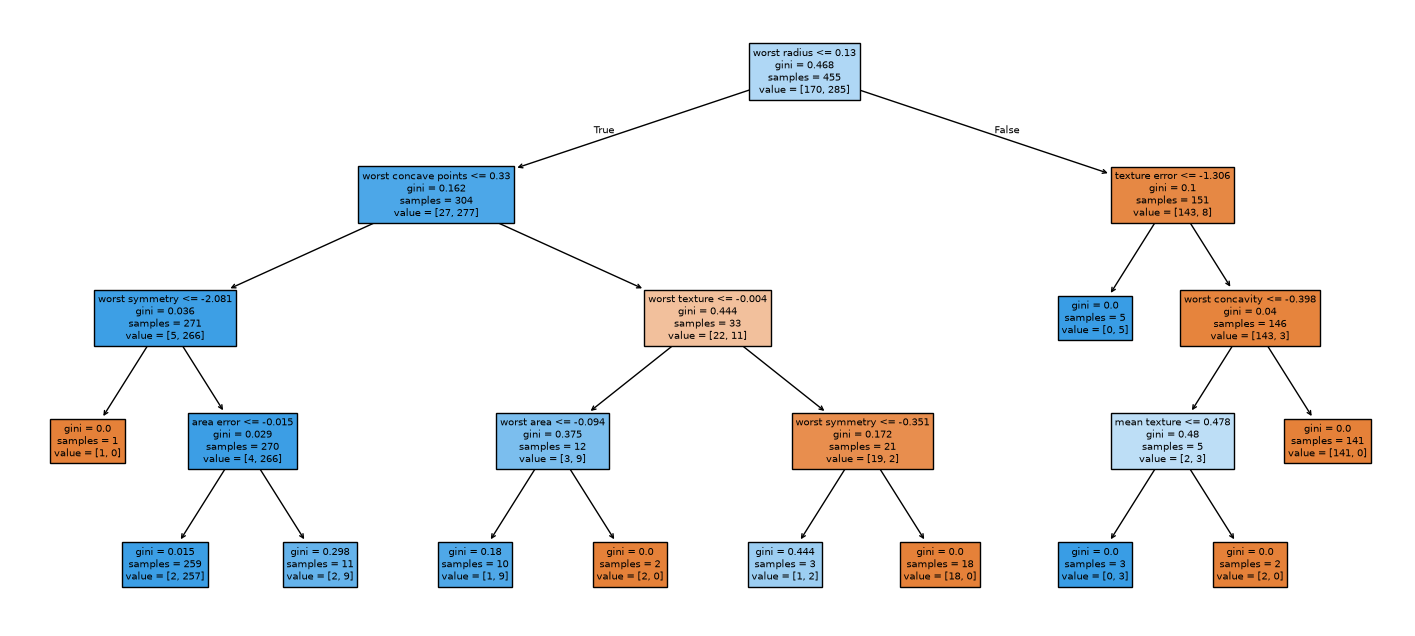

In [60]:
plt.figure(figsize=(18,8))
plot_tree(tree_4, feature_names=X_train.columns, filled=True)
plt.show()

**Respostas (Parte 4):**

1- A arvore teve um desempenho melhor com um número de profundidade (max_depth) maior(4), teve uma queda de qualidade quando o numero foi 2 e sem limite, mas o número de profundidade muito auto pode causar um overfitting, pois o modelo vai começar a decorar os dados e vai tentar entender exceções como regras, por isso devemos encontrar um equilíbrio

2- O modelo da árvore de decisão seria o mais fácil de explicar, pois o modelo basicamente indentifica e aprende regras que podem ser facilmente visualizadas em um gráfico, e podem servir até como aprendizado para agregar a tomada de decisão dos médicos ao indetificar um cancer

---
## ⚖️ Parte 5 — Comparação Final entre os Modelos (~25 min)

Com os dois modelos "finais" escolhidos (o melhor `k` do KNN e a melhor `max_depth` da Árvore),
é hora de colocá-los lado a lado.

**Façam:**

1. Gerem as **matrizes de confusão dos dois modelos lado a lado** (um gráfico ao lado do
   outro), com títulos e eixos claros indicando o que representa cada célula.
2. Montem uma **tabela comparativa** (pode ser um DataFrame simples) com, no mínimo:
   accuracy, precision, recall e f1-score de cada modelo — com destaque para os valores da
   classe "maligno".
3. Identifiquem, para cada modelo, **quantos falsos negativos** ele cometeu no conjunto de
   teste (tumores malignos classificados como benignos). Esse número é crítico no contexto
   hospitalar — expliquem por quê em uma célula de markdown.

**Perguntas para pensar (respondam em markdown):**
- Qual modelo teve o menor número de falsos negativos?
- Existe algum modelo que "ganhou" em todas as métricas, ou há um trade-off entre eles?

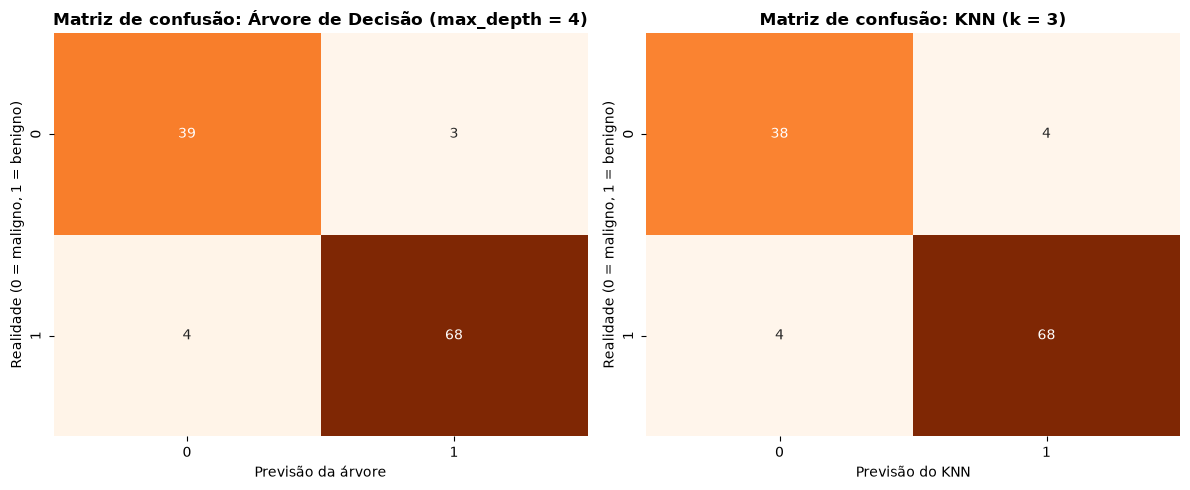

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# gráfico da ávore
sns.heatmap(confusion_matrix(y_test, tree_4_pred), annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[0])
axes[0].set_title('Matriz de confusão: Árvore de Decisão (max_depth = 4)', fontweight='bold')
axes[0].set_ylabel('Realidade (0 = maligno, 1 = benigno)')
axes[0].set_xlabel('Previsão da árvore')

# gráfico do KNN
sns.heatmap(confusion_matrix(y_test, knn_3_pred), annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1])
axes[1].set_title('Matriz de confusão: KNN (k = 3)', fontweight='bold')
axes[1].set_ylabel('Realidade (0 = maligno, 1 = benigno)')
axes[1].set_xlabel('Previsão do KNN')

plt.tight_layout()
plt.show()


In [78]:
tree_accuracy = accuracy_score(y_test, tree_4_pred)
tree_report = classification_report(y_test, tree_4_pred, output_dict=True)

# Métricas do KNN
knn_accuracy = accuracy_score(y_test, knn_3_pred)
knn_report = classification_report(y_test, knn_3_pred, output_dict=True)

# Montando a tabela comparativa (classe '0' = maligno)
comparison = pd.DataFrame({
    'Modelo': ['Árvore de Decisão (max_depth=4)', 'KNN (k=3)'],
    'Accuracy': [tree_accuracy, knn_accuracy],
    'Precision (maligno)': [tree_report['0']['precision'], knn_report['0']['precision']],
    'Recall (maligno)': [tree_report['0']['recall'], knn_report['0']['recall']],
    'F1-score (maligno)': [tree_report['0']['f1-score'], knn_report['0']['f1-score']],
    'Precision (benigno)': [tree_report['1']['precision'], knn_report['1']['precision']],
    'Recall (benigno)': [tree_report['1']['recall'], knn_report['1']['recall']],
    'F1-score (benigno)': [tree_report['1']['f1-score'], knn_report['1']['f1-score']],
})

comparison

,Modelo,Accuracy,Precision (maligno),Recall (maligno),F1-score (maligno),Precision (benigno),Recall (benigno),F1-score (benigno)
0,Árvore de Decisão (max_depth=4),0.938596,0.906977,0.928571,0.917647,0.957746,0.944444,0.951049
1,KNN (k=3),0.929825,0.904762,0.904762,0.904762,0.944444,0.944444,0.944444


**Respostas (Parte 5):**

_Escrevam aqui as respostas das perguntas acima._

1- o modelo da árvore de decisão teve o menor número de falsos negativos (3)

2- o resultado dos modelos foi extremamente similar, mas o modelo da árvore de decisão com max_depth = 3 se saiu um pouco melhor, tendo o maior número de verdadeiros negativos e o menor número de falsos negativos. Isso é extremamente importante pois é essa diferença pequena que pode salvar vidas, quanto menor for a taxa de falsos negativos menor serão as previsões que custam vidas

---
## 📋 Parte 6 — Relatório de Recomendação para o Hospital (~15 min)

Chegou a hora de traduzir o trabalho técnico em uma recomendação de negócio/clínica. Escrevam,
na célula de markdown abaixo, um pequeno relatório (não precisa ser longo — 1 a 2 parágrafos
por pergunta) respondendo:

1. **Qual dos dois modelos vocês recomendam para o hospital usar como apoio ao diagnóstico, e
   por quê?** Justifiquem com base nas métricas observadas (especialmente o recall da classe
   maligna) e não apenas na acurácia geral.
2. **Quais são os riscos de cada modelo** neste contexto clínico específico (pensem em falsos
   negativos vs falsos positivos)?
3. **Interpretabilidade:** qual modelo seria mais fácil de "explicar" para a equipe médica, e
   isso importa na decisão final?
4. **Limitações do estudo:** o que vocês apontariam como limitação deste experimento para o
   hospital (ex: tamanho da amostra, necessidade de validação com mais dados, necessidade de
   validação cruzada, um modelo de ML nunca deve substituir o diagnóstico médico, etc.)?
5. **Próximos passos:** se a equipe tivesse mais tempo, o que vocês testariam a seguir (outros
   algoritmos, ajuste fino mais completo, mais dados, outras métricas)?

> ⚠️ Lembrete importante para o relatório: um modelo de Machine Learning em um contexto médico
> é uma ferramenta de **apoio à decisão**, nunca um substituto do julgamento clínico do
> médico.

### ✍️ Relatório

**Nomes:** 

**1. Recomendação:**

Recomendo utilizar o modelo da árvore de decisão com max_depth 4, pois foi o modelo que apresentou o menor número de falsos negativos (dizer que era benígno enquanto era maligno) tendo um precision maior número de verdadeiros negativos (dizer que era maligno e realmente ser) tendo um precision de 0.90 e um recall de 0.92 para casos de cancer maligno

**2. Riscos de cada modelo:**

Ambos os modelos tem riscos mas a árvode de decisão definitivamente se saio com menos riscos sem trade off, mas o ricos principal é os casos em que ele pode dar falsos negativos (dizer que é benigno e não ser) mas este modelo é o modelo que teve a menor taxa de falsos negativos, mas ainda há o risco que pode custar uma vida

**3. Interpretabilidade:**

O modelo mais fácil de explicar seria a arvore de decisão, pois possui uma lógica clara e facil de visualizar, sendo basicamente uma árvore de decisão, além de que ela pode ajudar os próprios médicos a identificarem os casos, pois apresenta regras claras que talvez os médicos não tenham percebido

**4. Limitações do estudo:**

A maior limitação que vejo neste estudo é o fato de que é inseguro substituir uma avaliação médica por um ML, sempre havera o risco de o modelo errar, por isso a forma mais recomendada de usar o modelo treinado e escolhido aqui é como um auxilio, ou uma segunda opnião em caso de incerteza, mas a palavra final deve ser do médico

**5. Próximos passos:**

Provavelmente o mais prudente a se fazer a seguir seria testar outros algoritmos e parametros para avaliar e tentar chegar em um modelo que pelo menos tenha uma taxa de falsos negativos (dizer que é benigno e se maligno) menor, mesmo que em troca sacrifique a acurácia para outras métricas

Outra coisa importante seria uma coleta de dados maior para que os modelos possam aprender com mais dados e casos diferentes, assim enriquecendo os modelos

---
## ✅ Critérios de Entrega

Ao final das 2h30min, deverá ser entregue este notebook com:

- [ ] Todas as células de código executadas sem erro, do início ao fim;
- [ ] KNN treinado, testado com múltiplos valores de `k`, e avaliado;
- [ ] Árvore de Decisão treinada, testada com múltiplas profundidades, e avaliada;
- [ ] Matrizes de confusão comparativas dos dois modelos;
- [ ] Tabela comparativa de métricas;
- [ ] Todas as perguntas "para pensar" respondidas nas células de markdown correspondentes;
- [ ] Relatório final (Parte 6) preenchido.
